# Spaceship Titanic — Exploratory Data Analysis

**Notebook 01 of 3** — EDA and initial data understanding.

## Competition Overview

The Spaceship Titanic was hit by a spacetime anomaly en route to three habitable exoplanets. Almost half of the passengers were transported to an alternate dimension. Our task is to predict which passengers were transported, based on records recovered from the ship's damaged computer system.

This is a **binary classification** problem with the target variable `Transported` (True/False).

## Dataset

- **Training set:** ~8,700 passengers with known `Transported` labels
- **Test set:** ~4,300 passengers with unknown labels (for Kaggle submission)

## Notebook Structure

1. Setup and Data Loading
2. Initial Data Inspection
3. Target Variable Analysis
4. Missing Values Analysis
5. Categorical Features
6. Numerical Features
7. Feature Relationships with Target
8. Key Findings and Next Steps

## 1. Setup and Data Loading

**Goal:** Import libraries and load both `train.csv` and `test.csv`.

**Hints:**
- Standard imports you'll need: `numpy`, `pandas`, `matplotlib.pyplot`, `seaborn`
- Useful display settings: `pd.set_option('display.max_columns', None)` so wide dataframes show all columns
- Consider setting a `RANDOM_STATE = 42` constant for reproducibility later
- Load **both** `train` and `test` from `../data/raw/`. Even though we won't compute stats on test, we want to inspect it to confirm columns match and plan preprocessing
- After loading, print `.shape` for both and verify which column exists in train but not test (that's your target)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
RANDOM_STATE = 42

In [2]:
train = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')

In [3]:
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train shape: (8693, 14)
Test shape:  (4277, 13)


In [4]:
print(f"Columns in train but not test: {set(train.columns) - set(test.columns)}")

Columns in train but not test: {'Transported'}


In [5]:
target = "Transported"

## 2. Initial Data Inspection

**Goal:** Get a first look at the data — column types, sample rows, basic statistics.

**Hints:**
- `.head()` to see the first few rows
- `.info()` to see dtypes and non-null counts
- `.describe()` for numerical summary stats
- `.describe(include='object')` for categorical columns

**Things to look for:**
- What are the column types? (numerical vs categorical vs boolean)
- Which columns have missing values?
- Do any numerical columns have suspicious min/max values (e.g., negative spending)?
- Does `PassengerId` have a pattern? (look closely at the format)

In [6]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 1.2+ MB


In [8]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [9]:
train.isna().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [10]:
train['PassengerId'].str.split('_')

0       [0001, 01]
1       [0002, 01]
2       [0003, 01]
3       [0003, 02]
4       [0004, 01]
           ...    
8688    [9276, 01]
8689    [9278, 01]
8690    [9279, 01]
8691    [9280, 01]
8692    [9280, 02]
Name: PassengerId, Length: 8693, dtype: object

In [11]:
train['PassengerId'].str.split('_').str[1].value_counts()

PassengerId
01    6217
02    1412
03     571
04     231
05     128
06      75
07      46
08      13
Name: count, dtype: int64

In [12]:
train['PassengerId'].str.split('_').str[0].value_counts()

PassengerId
0984    8
4005    8
4256    8
4498    8
5133    8
       ..
9270    1
9274    1
9276    1
9278    1
9279    1
Name: count, Length: 6217, dtype: int64

### Observations

- Training set has 8,693 rows and 14 columns (13 features + 1 target)
- Test set has 4,277 rows and 13 columns (no `Transported` column, as expected)
- `CryoSleep` and `VIP` are stored as `object` dtype despite being boolean — this is because pandas cannot store NaN in a true boolean column
- Every column except `PassengerId` and `Transported` has missing values, all in the ~2-3% range — manageable, no column is catastrophically missing
- Spending columns (`RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`) are heavily right-skewed — median is $0 $ for all five, but max values reach $14,000 - $29,000|
- `Cabin` has structure `Deck/Num/Side` (e.g., `B/0/P`) — will parse into three separate features in notebook 02
- `PassengerId` has structure `gggg_pp` where `gggg` is group ID and `pp` is position within group — will engineer `GroupSize` and `IsAlone` features in notebook 02
- Roughly 55% of passengers appear to be traveling alone based on group ID analysis
- Mean spending is ~$225 for RoomService but median is $0 — more than half of 
  passengers spent nothing; distribution is heavily right-skewed due to a small 
  number of high spenders

## 3. Target Variable Analysis

**Goal:** Understand the distribution of the target variable `Transported`.

**Why this matters:** If the classes are very imbalanced (e.g., 95%/5%), accuracy becomes a misleading metric and we'd need to consider stratified sampling, class weights, or oversampling. If they're balanced (~50/50), accuracy is a reasonable default metric.

**Hints:**
- `.value_counts()` for raw counts
- `.value_counts(normalize=True)` for proportions
- A simple bar plot makes the balance visually obvious (`sns.countplot` or `.value_counts().plot(kind='bar')`)

In [13]:
# Class distribution — counts and proportions
print("Counts:")
print(train[target].value_counts())
print("\nProportions:")
print(train[target].value_counts(normalize=True).round(3))

Counts:
Transported
True     4378
False    4315
Name: count, dtype: int64

Proportions:
Transported
True     0.504
False    0.496
Name: proportion, dtype: float64


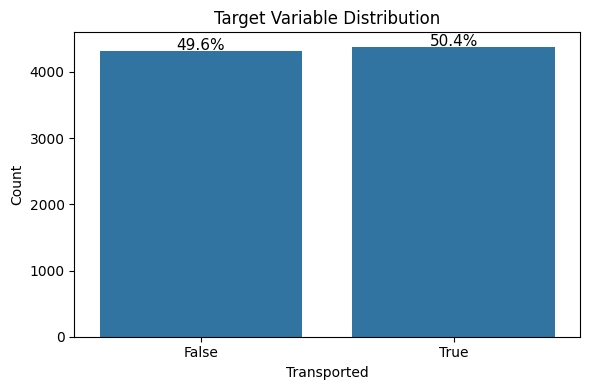

In [14]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.countplot(x=target, data=train, ax=ax)

ax.set_title('Target Variable Distribution')
ax.set_xlabel('Transported')
ax.set_ylabel('Count')

# Add percentage labels on top of each bar
total = len(train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2, p.get_height() + 20),
                ha='center', fontsize=11)

plt.tight_layout()
plt.show()

### Observations

- Classes are nearly balanced: X% Transported vs Y% Not Transported
- Because classes are balanced, **accuracy is a reasonable primary metric**
- No need for class weighting or oversampling techniques

## 4. Missing Values Analysis

**Goal:** Identify how much is missing per column and whether missingness itself might be informative.

**Why this matters:** Before we can impute, we need to know the scope. Also, sometimes a missing value is *itself* a signal (e.g., if wealthy passengers are less likely to report their cabin, missingness correlates with the target).

**Hints:**
- `.isnull().sum()` gives missing counts per column
- Divide by `len(train)` and multiply by 100 for percentages
- Consider building a small summary DataFrame with count and percentage columns, sorted descending
- A heatmap of `df.isnull()` (using `sns.heatmap`) can reveal patterns — do rows tend to have multiple missing values together, or are missing values scattered?

**Stretch exercise:** For each column with missing values, check whether `Transported` rate differs between rows where that column is missing vs not missing. If it does, the missingness itself carries predictive signal.

In [15]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [16]:
(train.isnull().sum() / len(train)) *100

PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Name            2.300702
Transported     0.000000
dtype: float64

In [17]:
cols_missing = train.isnull().sum()
pcnt_missing = (train.isnull().sum() / len(train)) * 100

missingness = pd.DataFrame({
    'missing_count': cols_missing,
    'missing_pct': pcnt_missing.round(2)
}).sort_values(by='missing_count', ascending=False)

missingness

,missing_count,missing_pct
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
Spa,183,2.11
FoodCourt,183,2.11
Destination,182,2.09


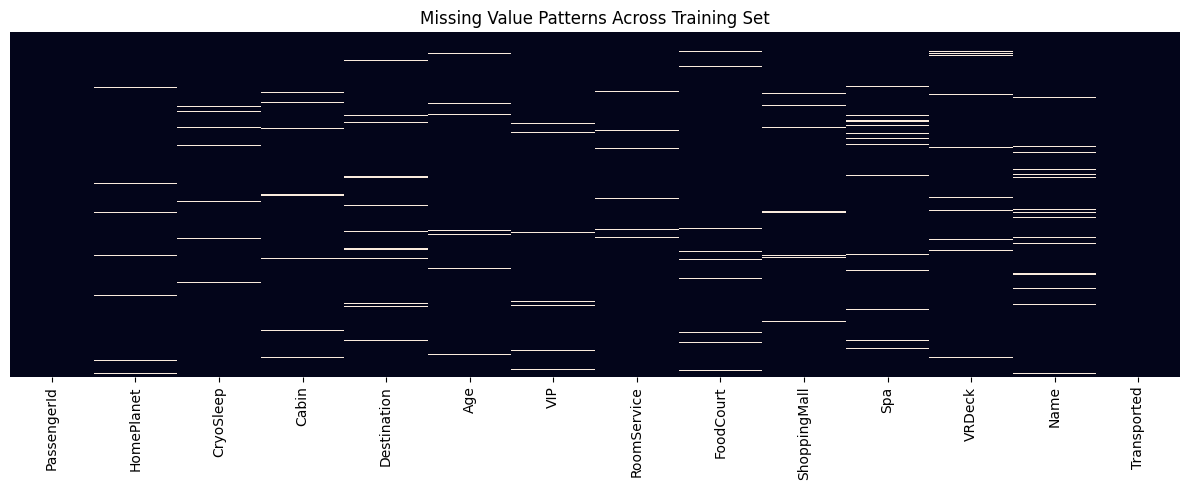

In [18]:
plt.figure(figsize=(12, 5))
sns.heatmap(train.isnull(), 
            cbar=False, 
            yticklabels=False)
plt.title('Missing Value Patterns Across Training Set')
plt.tight_layout()
plt.show()

In [19]:
print(train.groupby(train['CryoSleep'].isnull())['Transported'].mean())

CryoSleep
False    0.504011
True     0.488479
Name: Transported, dtype: float64


In [20]:
for cols in train.columns:
    print(train.groupby(train[cols].isnull())['Transported'].mean())

PassengerId
False    0.503624
Name: Transported, dtype: float64
HomePlanet
False    0.503415
True     0.512438
Name: Transported, dtype: float64
CryoSleep
False    0.504011
True     0.488479
Name: Transported, dtype: float64
Cabin
False    0.503650
True     0.502513
Name: Transported, dtype: float64
Destination
False    0.503584
True     0.505495
Name: Transported, dtype: float64
Age
False    0.503641
True     0.502793
Name: Transported, dtype: float64
VIP
False    0.503416
True     0.512315
Name: Transported, dtype: float64
RoomService
False    0.504582
True     0.458564
Name: Transported, dtype: float64
FoodCourt
False    0.502820
True     0.540984
Name: Transported, dtype: float64
ShoppingMall
False    0.502534
True     0.548077
Name: Transported, dtype: float64
Spa
False    0.503760
True     0.497268
Name: Transported, dtype: float64
VRDeck
False    0.503233
True     0.521277
Name: Transported, dtype: float64
Name
False    0.503591
True     0.505000
Name: Transported, dtype: float6

### Observations

- All columns except `PassengerId` and `Transported` have missing values,
  all in the 2-3% range — no column is catastrophically missing
- Missing counts are all distinct, meaning missingness is scattered 
  independently across columns rather than entire rows being wiped
- Heatmap confirms no systematic vertical blocks — missingness appears 
  largely random (consistent with MCAR or mild MAR)
- Transport rate for passengers with missing `CryoSleep` (48.8%) vs 
  not missing (50.4%) is nearly identical — missingness carries no 
  meaningful signal for the target, safe to impute without an indicator feature
- Imputation strategy: median for numerical columns, mode for categoricals,
  computed on train only and applied to test

## 5. Categorical Features

**Goal:** Understand each categorical column's distribution and any obvious structure.

**Categorical columns:** `HomePlanet`, `CryoSleep`, `Cabin`, `Destination`, `VIP`, `Name`, and also `PassengerId` (which has internal structure).

**For each, we want to know:**
- What are the unique values?
- Is the distribution balanced or dominated by one category?
- Is there internal structure to parse out? (e.g., `Cabin` is `Deck/Num/Side`, `PassengerId` is `Group_NumberInGroup`)

### 5.1 PassengerId

**Hint:** The format is `gggg_pp` where `gggg` is the group ID and `pp` is the position within the group. People in the same group are often family or travel companions. This is a goldmine for feature engineering later (group size, traveling alone vs. with family, etc.) but for now, just confirm the format and count distinct groups.

In [21]:
train['PassengerId'].str.split('_').str[0].value_counts()

PassengerId
0984    8
4005    8
4256    8
4498    8
5133    8
       ..
9270    1
9274    1
9276    1
9278    1
9279    1
Name: count, Length: 6217, dtype: int64

In [22]:
train['PassengerId'].str.split('_').str[1].value_counts()

PassengerId
01    6217
02    1412
03     571
04     231
05     128
06      75
07      46
08      13
Name: count, dtype: int64

### 5.2 HomePlanet

**Hint:** `.value_counts()` will show you the three planets and their counts. Consider a simple bar plot.

Text(0, 0.5, 'HomePlanet Count')

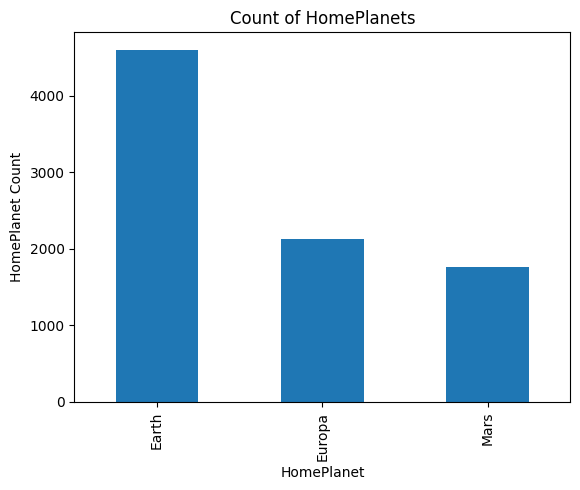

In [23]:
train["HomePlanet"].value_counts().plot(kind = 'bar')
plt.title('Count of HomePlanets')
plt.xlabel('HomePlanet')
plt.ylabel('HomePlanet Count')

In [24]:
train.groupby('HomePlanet')[target].mean().sort_values(ascending=False)

HomePlanet
Europa    0.658846
Mars      0.523024
Earth     0.423946
Name: Transported, dtype: float64

### 5.3 CryoSleep

**Hint:** CryoSleep is a boolean. Passengers in cryosleep are confined to their cabins — so we should expect their spending columns to all be zero. Worth checking this assumption.

In [25]:
train.groupby('CryoSleep')[['RoomService', 'FoodCourt', 'Spa']].mean()

,RoomService,FoodCourt,Spa
CryoSleep,,,
False,350.146772,713.004316,486.09294
True,0.000000,0.000000,0.00000


In [26]:
train.groupby('CryoSleep')[target].mean()

CryoSleep
False    0.328921
True     0.817583
Name: Transported, dtype: float64

### Observations — CryoSleep

- All passengers with CryoSleep=True spent exactly $0 across every 
  spending column — logical constraint, not just a statistical pattern
- This enables logical imputation in notebook 02: missing CryoSleep 
  values can be inferred from spending columns
- CryoSleep is one of the strongest predictors in the dataset:
    - CryoSleep=True  → 81.8% transport rate
    - CryoSleep=False → 32.9% transport rate
    - 50 percentage point gap from a single binary feature
- Zero spending partially explained by CryoSleep — TotalSpend=0 means 
  different things for sleeping vs awake passengers

### 5.4 Cabin

**Hint:** Format is `Deck/Number/Side` (e.g., `B/0/P`). You already parsed this in your previous notebook — use `.str.split('/')` to split into three new columns: `Cabin_Deck`, `Cabin_Num`, `Cabin_Side`. Then `.value_counts()` on each.

**Watch out for:** missing values. `.str.split` returns NaN for NaN input, which is what we want, but be careful if you convert `Cabin_Num` to int (NaN doesn't convert to int cleanly).

In [27]:
train["Cabin"].str.split('/')

0          [B, 0, P]
1          [F, 0, S]
2          [A, 0, S]
3          [A, 0, S]
4          [F, 1, S]
            ...     
8688      [A, 98, P]
8689    [G, 1499, S]
8690    [G, 1500, S]
8691     [E, 608, S]
8692     [E, 608, S]
Name: Cabin, Length: 8693, dtype: object

In [28]:
train["Cabin_Deck"] = train["Cabin"].str.split('/').str[0]

In [29]:
train.groupby('Cabin_Deck')[target].mean().sort_values(ascending=False)

Cabin_Deck
B    0.734275
C    0.680054
G    0.516217
A    0.496094
F    0.439871
D    0.433054
E    0.357306
T    0.200000
Name: Transported, dtype: float64

In [30]:
train.groupby(['HomePlanet', "Cabin_Deck"])[target].mean().sort_values(ascending=False)

HomePlanet  Cabin_Deck
Europa      B             0.733681
            C             0.677112
Mars        F             0.650450
Europa      D             0.586022
            E             0.546875
Earth       G             0.518014
Europa      A             0.496032
Earth       E             0.372152
Mars        D             0.333333
Earth       F             0.292441
Mars        E             0.260606
Europa      T             0.250000
Name: Transported, dtype: float64

In [31]:
train["Cabin_Num"] = train["Cabin"].str.split('/').str[1]

In [32]:
train["Cabin_Side"] = train["Cabin"].str.split('/').str[2]

In [33]:
train.groupby('Cabin_Side')[target].mean().sort_values(ascending=False)

Cabin_Side
S    0.555037
P    0.451260
Name: Transported, dtype: float64

### additional findings for Deck F

In [34]:
train[train['HomePlanet'] == 'Mars'].groupby('Cabin_Side')[target].mean()

Cabin_Side
P    0.500000
S    0.549161
Name: Transported, dtype: float64

In [35]:
train[train['HomePlanet'] == 'Mars'].groupby('Cabin_Deck')[target].mean()

Cabin_Deck
D    0.333333
E    0.260606
F    0.650450
Name: Transported, dtype: float64

### Observations — Cabin

- Cabin parses cleanly into Deck/Num/Side with no unexpected values except 
  Deck T (only 5 passengers — treat as rare category in preprocessing)
- Strong transport rate signal by deck:
    - High transport: B (73%), C (68%)
    - Mid transport: G (52%), A (50%)  
    - Low transport: F (44%), D (43%), E (36%)
- Deck likely correlates with HomePlanet — B/C are Europa passengers, 
  F/G are Earth passengers — will check for multicollinearity later
- Cabin_Side split is nearly 50/50 (P vs S) — will check transport 
  rate by side

### 5.5 Destination

**Hint:** Three destinations. Simple `.value_counts()` and a bar plot.

Text(0, 0.5, 'Destinations Count')

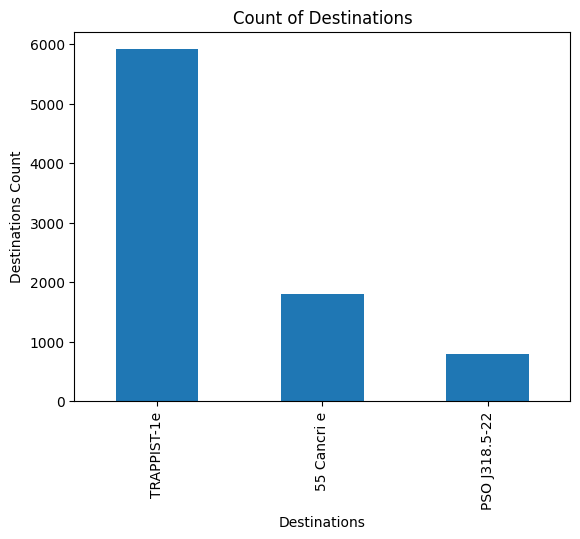

In [36]:
train["Destination"].value_counts().plot(kind = "bar")
plt.title('Count of Destinations')
plt.xlabel('Destinations')
plt.ylabel('Destinations Count')

In [37]:
train.groupby('Destination')[target].mean().sort_values(ascending=False)

Destination
55 Cancri e      0.610000
PSO J318.5-22    0.503769
TRAPPIST-1e      0.471175
Name: Transported, dtype: float64

### 5.6 VIP

**Hint:** Boolean. Expect this to be very imbalanced (few VIPs). Worth noting how rare VIP is — with so few examples, this feature may not be very predictive on its own.

In [38]:
train["VIP"].value_counts()

VIP
False    8291
True      199
Name: count, dtype: int64

In [39]:
train.groupby('VIP')[target].mean()

VIP
False    0.506332
True     0.381910
Name: Transported, dtype: float64

### 5.7 Name

**Hint:** Names are mostly unique. The interesting signal might be in **last names** (family groupings). Try splitting into `FirstName` and `LastName` using `.str.split(' ')` and see how many passengers share a last name. Later, we may engineer a family-size feature from this combined with the group ID.

In [40]:
train["Name"].str.split(" ")

0         [Maham, Ofracculy]
1            [Juanna, Vines]
2           [Altark, Susent]
3            [Solam, Susent]
4       [Willy, Santantines]
                ...         
8688    [Gravior, Noxnuther]
8689      [Kurta, Mondalley]
8690         [Fayey, Connon]
8691     [Celeon, Hontichre]
8692     [Propsh, Hontichre]
Name: Name, Length: 8693, dtype: object

In [41]:
train["FirstName"] = train["Name"].str.split(" ").str[0]

In [42]:
train["LastName"] = train["Name"].str.split(" ").str[1]

In [43]:
train["LastName"].value_counts()

LastName
Casonston     18
Oneiles       16
Litthews      15
Domington     15
Garnes        14
              ..
Valing         1
Maglible       1
Howence        1
Fort           1
Sionerorly     1
Name: count, Length: 2217, dtype: int64

In [44]:
# Do passengers with common surnames cluster by HomePlanet?
common_surnames = train['LastName'].value_counts().head(10).index
train[train['LastName'].isin(common_surnames)].groupby('LastName')['HomePlanet'].value_counts()

LastName    HomePlanet
Briggston   Earth         13
Browlerson  Earth         14
Cartez      Earth         14
Casonston   Earth         18
Domington   Earth         15
Fulloydez   Earth         14
Garnes      Earth         14
Litthews    Earth         15
Moodman     Earth         13
Oneiles     Earth         16
Name: count, dtype: int64

### Observations — Categorical Features Summary

- HomePlanet is strongly predictive: Europa (66%) > Mars (52%) > Earth (42%)
- HomePlanet and Cabin_Deck are correlated — Europa clusters in B/C, 
  Earth clusters in F/G — they partially encode the same signal
- VIP has a lower transport rate (38%) than non-VIP (51%) — likely 
  confounded by spending behavior rather than a direct causal relationship
- Cabin_Side: Starboard (55%) vs Port (45%) — consistent 10pt gap
- Key interaction found: Mars/Deck F transports at 65% vs Earth/Deck F 
  at 29% — same deck, very different rates by planet. Tree models will 
  capture this naturally, Logistic Regression will not

## 6. Numerical Features

**Goal:** Understand each numerical column's distribution.

**Numerical columns:** `Age`, `RoomService`, `FoodCourt`, `ShoppingMall`, `Spa`, `VRDeck`.

**Key questions:**
- What's the shape of the distribution? (normal, skewed, bimodal?)
- Are there outliers?
- Do the spending columns share a common pattern? (spoiler: lots of zeros, long tails)

### 6.1 Age

**Hint:** Histogram (`sns.histplot` or `plt.hist`). Also consider a boxplot. What's the age range? Are there children (age 0) that might behave differently from adults?

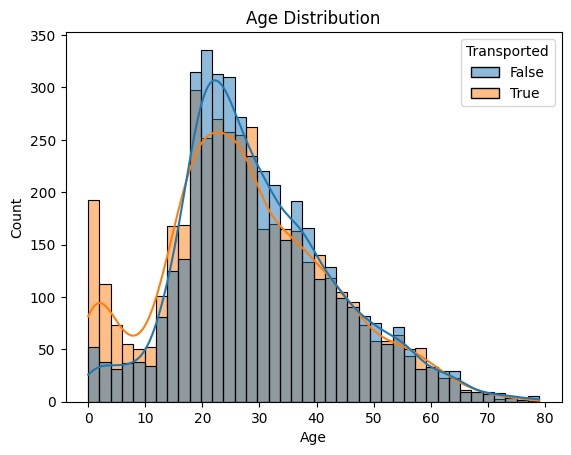

In [45]:
sns.histplot(data = train, x = "Age", kde = True, hue = target, bins = 40)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### Observations — Age

- Distribution is roughly unimodal with peak around age 25, 
  steadily declining through older ages
- Notable spike at age 0 (infants) with ~67% transport rate — 
  possibly related to higher CryoSleep rates for infants
- Transport rate is approximately 50/50 for ages 10+ meaning 
  raw age has limited linear predictive power for adults
- Will engineer `AgeBin` feature in notebook 02 to capture 
  the child vs adult threshold effect that tree models would 
  find naturally but Logistic Regression would miss
- KDE curves cross at approximately age 12-15, confirming the 
  child threshold effect visually — under 12 skews transported, 
  12+ is approximately 50/50

### 6.2 Spending Columns (RoomService, FoodCourt, ShoppingMall, Spa, VRDeck)

**Hint:** These columns will be heavily right-skewed (most passengers spent $0, a few spent thousands). Consider:
- A histogram for each — they'll look ugly because of the zeros
- Try a log-scale y-axis, or plot `np.log1p(column)` (log of 1+x, which handles zeros)
- The proportion of zeros per column is itself an interesting statistic

**Feature engineering idea for later:** a `TotalSpend` column (sum of all five), and a `HasSpent` boolean.

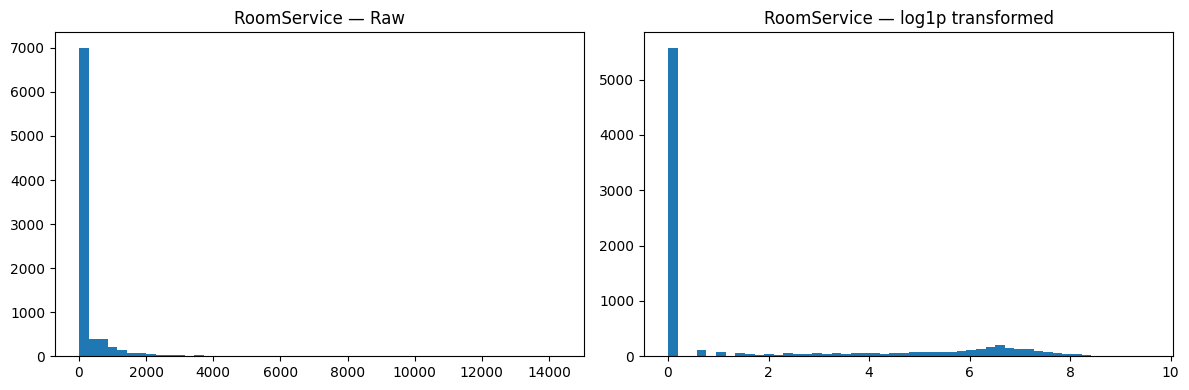

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train['RoomService'].dropna(), bins=50)
axes[0].set_title('RoomService — Raw')

axes[1].hist(np.log1p(train['RoomService'].dropna()), bins=50)
axes[1].set_title('RoomService — log1p transformed')

plt.tight_layout()
plt.show()

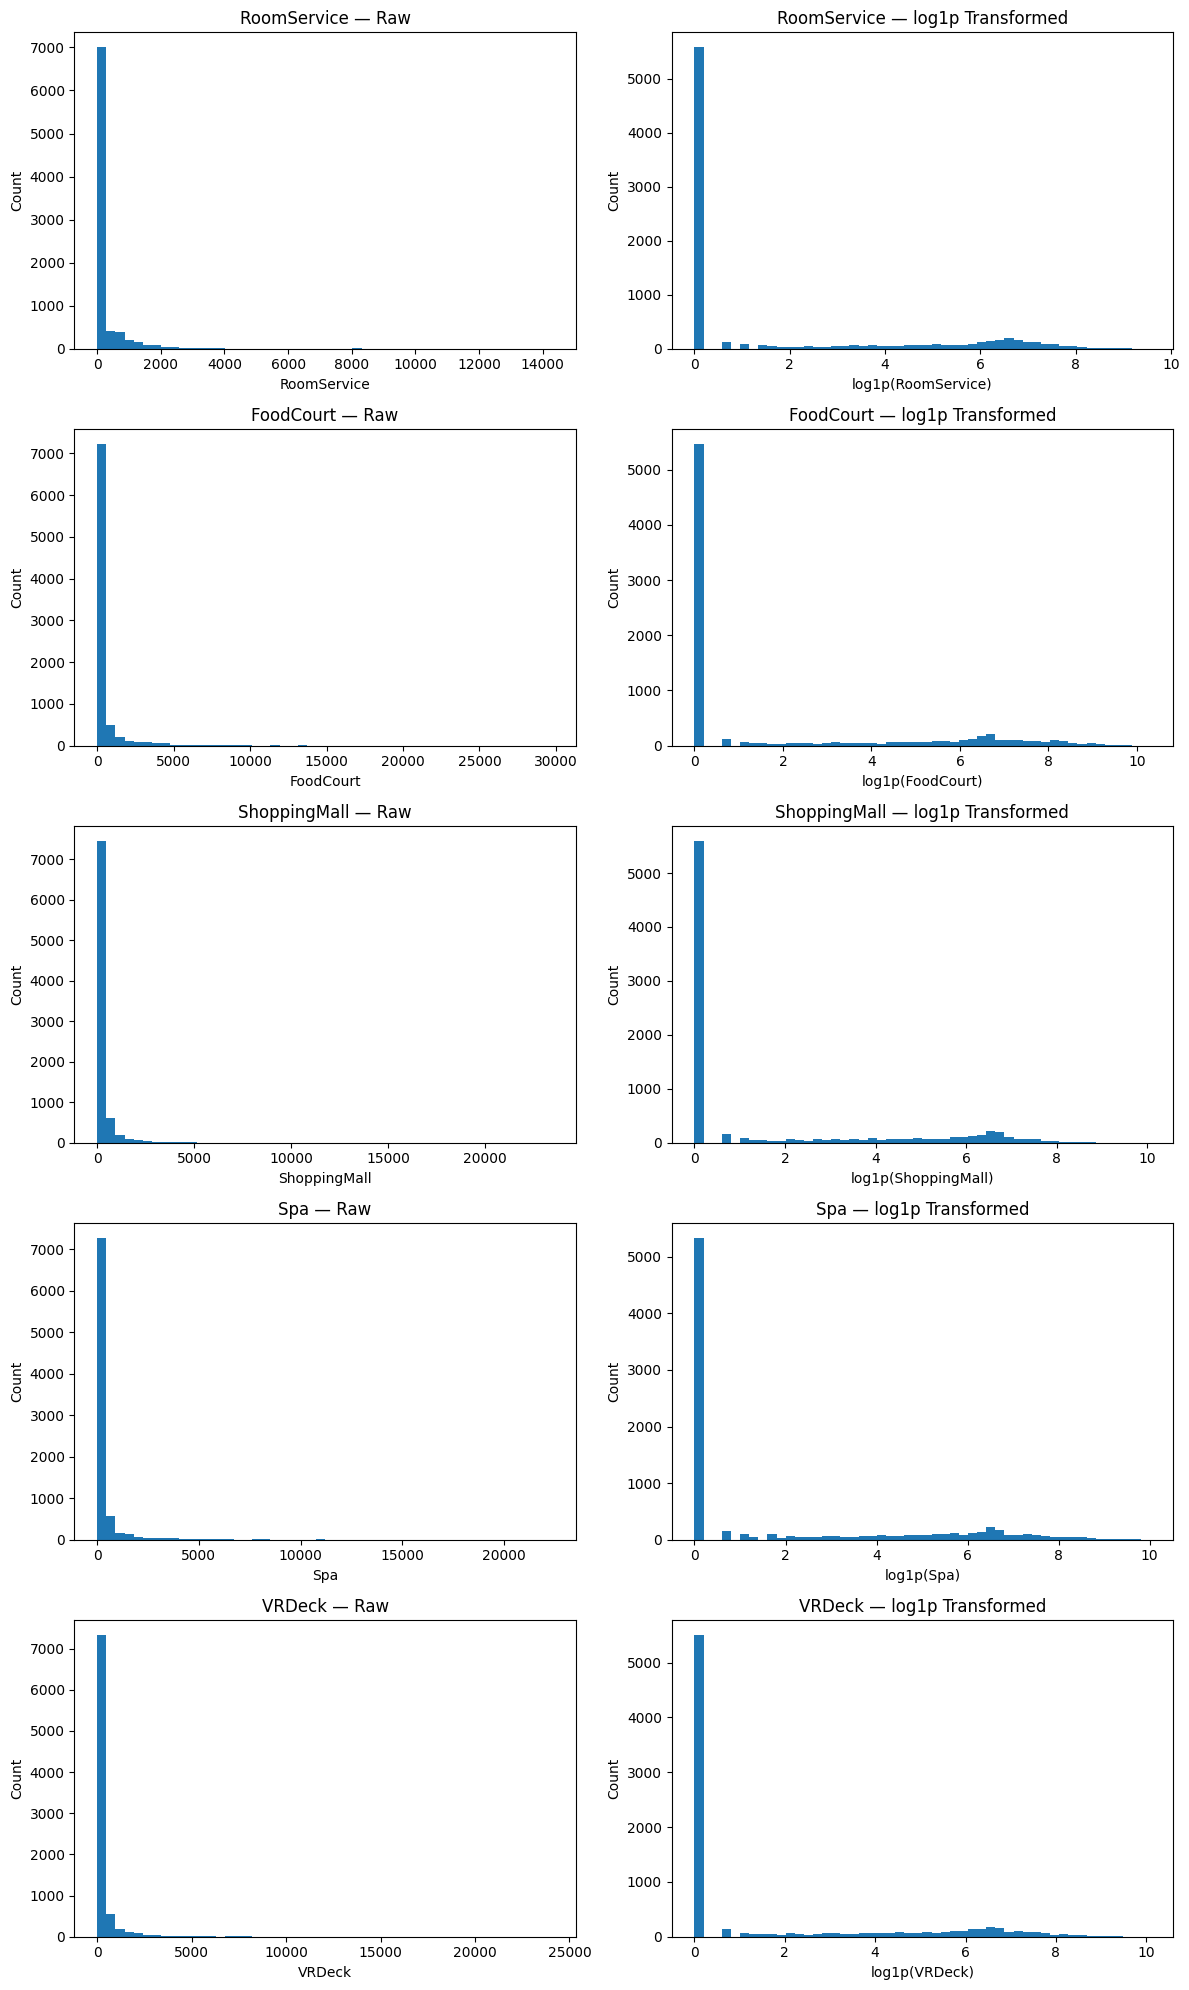

In [47]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(len(spend_cols), 2, figsize=(12, 20))

for i, col in enumerate(spend_cols):
    # Left plot — raw
    axes[i, 0].hist(train[col].dropna(), bins=50)
    axes[i, 0].set_title(f'{col} — Raw')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')
    
    # Right plot — log1p transformed
    axes[i, 1].hist(np.log1p(train[col].dropna()), bins=50)
    axes[i, 1].set_title(f'{col} — log1p Transformed')
    axes[i, 1].set_xlabel(f'log1p({col})')
    axes[i, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

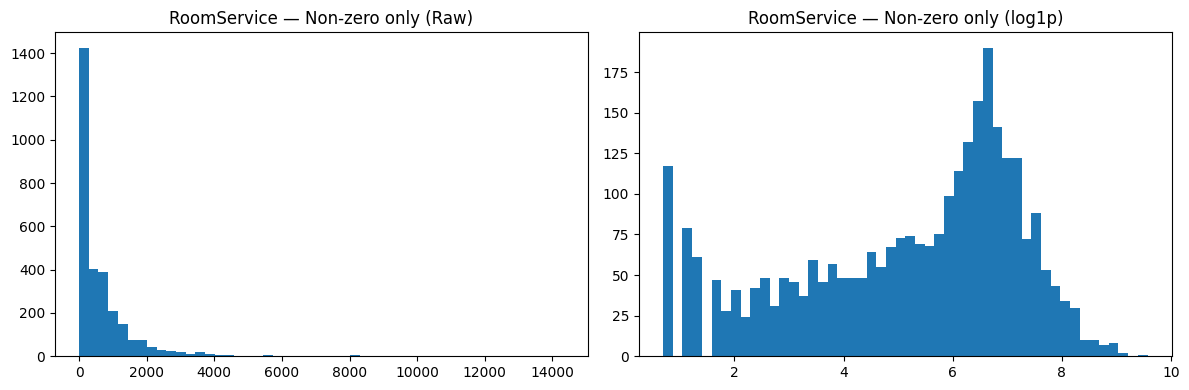

In [48]:
# Look at only passengers who actually spent something
spenders = train[train['RoomService'] > 0]['RoomService']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(spenders, bins=50)
axes[0].set_title('RoomService — Non-zero only (Raw)')

axes[1].hist(np.log1p(spenders), bins=50)
axes[1].set_title('RoomService — Non-zero only (log1p)')

plt.tight_layout()
plt.show()

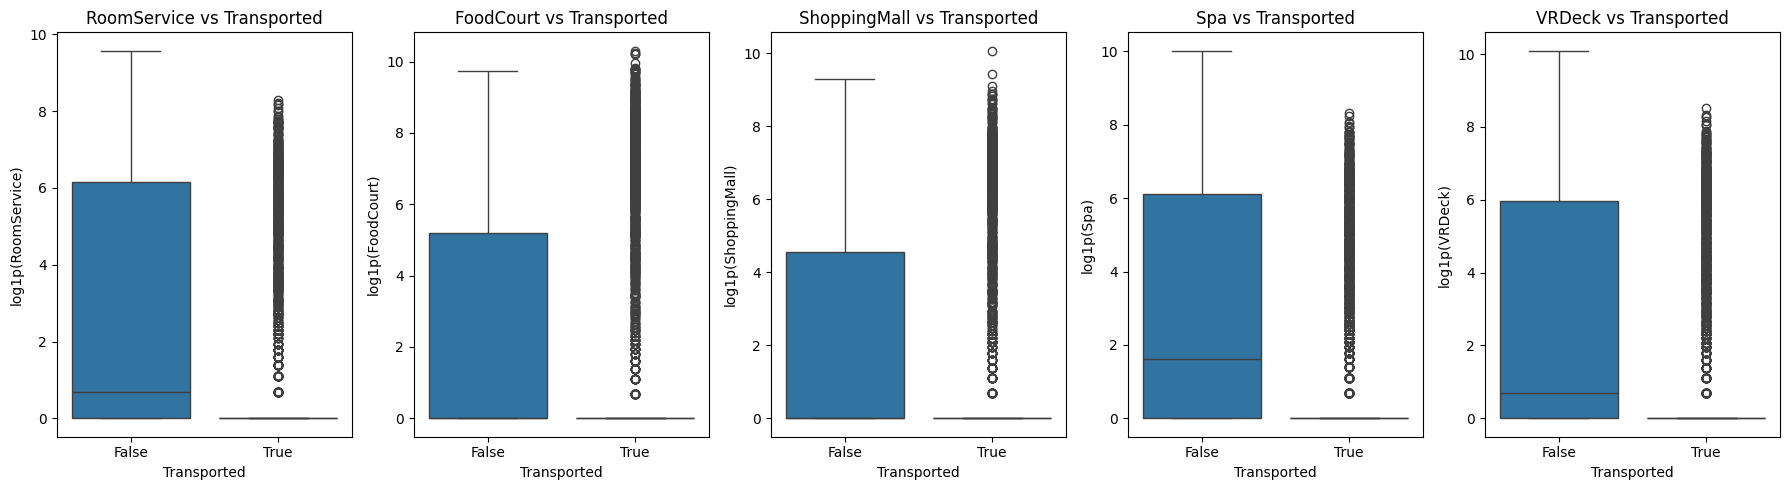

In [49]:
fig, axes = plt.subplots(1, len(spend_cols), figsize=(18, 5))

for i, col in enumerate(spend_cols):
    sns.boxplot(x=target, y=np.log1p(train[col]), data=train, ax=axes[i])
    axes[i].set_title(f'{col} vs Transported')
    axes[i].set_xlabel('Transported')
    axes[i].set_ylabel(f'log1p({col})')

plt.tight_layout()
plt.show()

### Observations — Spending Columns (Boxplots)

- RoomService, Spa, VRDeck all show higher median spending for 
  Transported=False — these are leisure amenities, active enjoyment 
  of the ship correlates with not being transported
- FoodCourt and ShoppingMall show approximately equal medians 
  across both classes — utility spending is not predictive
- Will engineer LeisureSpend and UtilitySpend separately in 
  notebook 02 to capture this distinction

## 7. Feature Relationships with Target

**Goal:** For each feature, does it seem related to `Transported`? This is where we find the signals our model will exploit.

**Important distinction to keep in mind:** there's a difference between **count** (how many passengers with this value were transported) and **rate / proportion** (what fraction of passengers with this value were transported). The rate is usually what matters for modeling. For example, 'Deck G has the most transported passengers' is usually because Deck G has the most passengers — not because G has a high transport rate.

### 7.1 Categorical features vs Transported

**Hint:** For each categorical feature (`HomePlanet`, `CryoSleep`, `Destination`, `VIP`, `Cabin_Deck`, `Cabin_Side`), compute the transport **rate** per category.

Two useful patterns:
- `df.groupby('HomePlanet')['Transported'].mean()` — since `Transported` is boolean, mean gives you the rate of True
- `sns.countplot(x='HomePlanet', hue='Transported', data=train)` — stacked bars showing the split

**Look for:** features where the transport rate differs noticeably across categories. Those are your predictive features.

In [62]:
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Cabin_Deck', 'Cabin_Side']

for col in cat_cols:
    print(f"--- {col} ---")
    print(train.groupby(col)[target].mean())
    print("\n")

--- HomePlanet ---
HomePlanet
Earth     0.423946
Europa    0.658846
Mars      0.523024
Name: Transported, dtype: float64


--- CryoSleep ---
CryoSleep
False    0.328921
True     0.817583
Name: Transported, dtype: float64


--- Destination ---
Destination
55 Cancri e      0.610000
PSO J318.5-22    0.503769
TRAPPIST-1e      0.471175
Name: Transported, dtype: float64


--- VIP ---
VIP
False    0.506332
True     0.381910
Name: Transported, dtype: float64


--- Cabin_Deck ---
Cabin_Deck
A    0.496094
B    0.734275
C    0.680054
D    0.433054
E    0.357306
F    0.439871
G    0.516217
T    0.200000
Name: Transported, dtype: float64


--- Cabin_Side ---
Cabin_Side
P    0.451260
S    0.555037
Name: Transported, dtype: float64




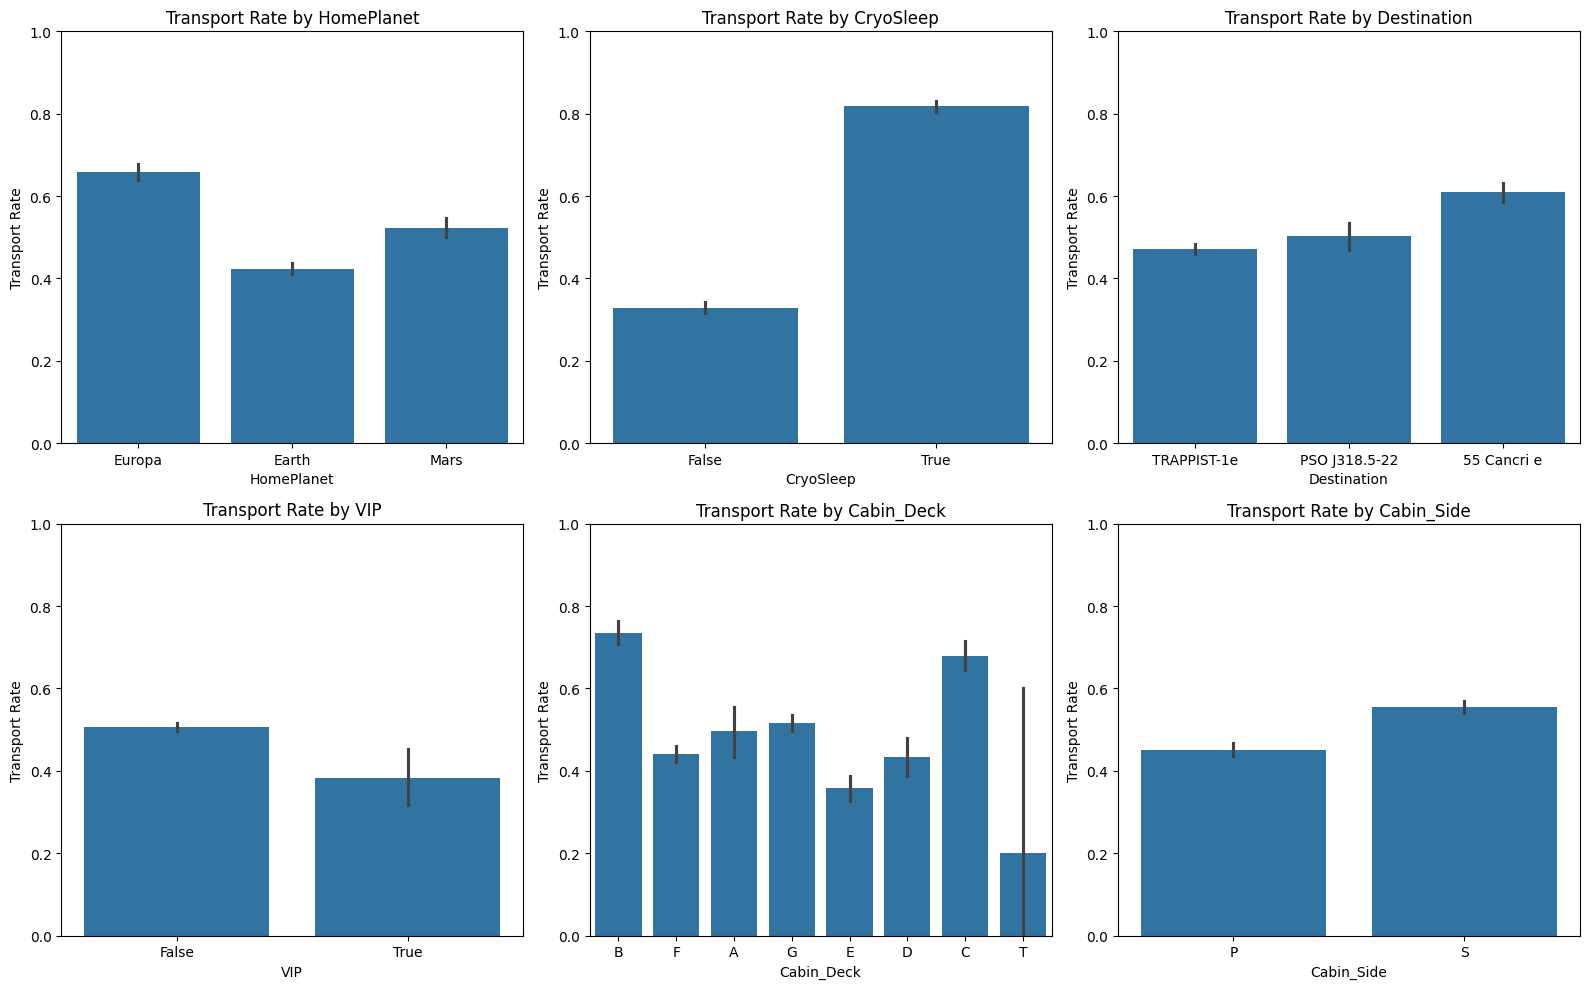

In [64]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.barplot(x=col, y=target, data=train, 
                ax=axes[i], estimator='mean')
    axes[i].set_title(f'Transport Rate by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Transport Rate')
    axes[i].set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Observations — Categorical Features vs Transported

- CryoSleep is the dominant categorical predictor — 82% transport 
  rate when True vs 33% when False, a 50 point gap no other feature 
  approaches
- Cabin_Deck shows strong signal: B (73%) and C (68%) are high-transport 
  decks, E (36%) and T (20%) are low — but Deck T has only 5 passengers 
  so its rate is unreliable (visible in wide confidence interval)
- HomePlanet: Europa (66%) > Mars (52%) > Earth (42%) — likely 
  correlated with Cabin_Deck assignment
- Destination: 55 Cancri e passengers transport at 61%, notably 
  higher than TRAPPIST-1e (47%)
- Cabin_Side: Starboard (55%) vs Port (45%) — consistent but modest gap
- VIP transports at lower rate (38%) than non-VIP (50%) — counterintuitive, 
  likely confounded by higher leisure spending among VIPs
- Consistent y-axis (0 to 1) across all plots makes gaps directly 
  comparable — CryoSleep gap is visually ~3x larger than any other feature

### 7.2 Numerical features vs Transported

**Hint:** For each numerical feature:
- Boxplot split by target: `sns.boxplot(x='Transported', y='Age', data=train)`
- Or overlapping histograms
- For spending columns, compare median spending (not mean — mean is distorted by outliers) between Transported=True and False

**Look for:** features where the distribution shifts between the two classes. If transported passengers spend less on RoomService on average, that's a signal.

In [69]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
 14  Cabin_Deck    8494 non-null   object 
 15  Cabin_Num     8494 non-null   object 
 16  Cabin_Side    8494 non-null   object 
 17  FirstName     8493 non-null   object 
 18  LastName      8493 non-null   object 
d

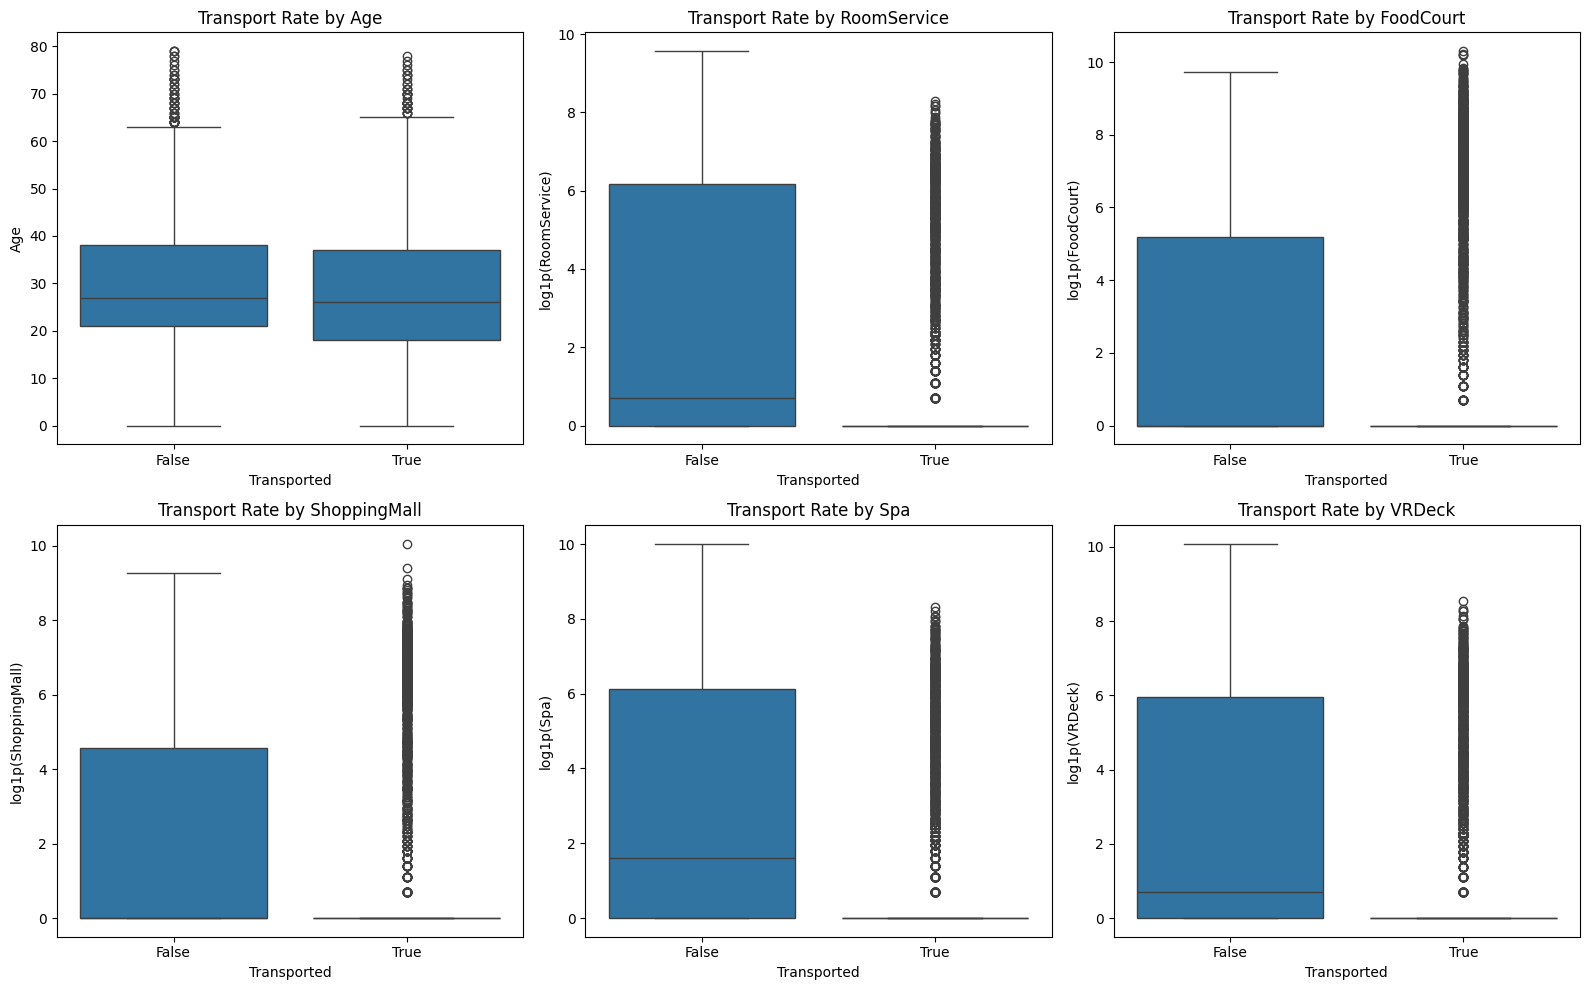

In [76]:
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Apply log1p to spending columns but not Age
    x_data = np.log1p(train[col]) if col != 'Age' else train[col]
    
    sns.boxplot(x=target, y=x_data, data=train, ax=axes[i])
    axes[i].set_title(f'Transport Rate by {col}')
    axes[i].set_xlabel('Transported')
    axes[i].set_ylabel(f'log1p({col})' if col != 'Age' else col)  

plt.tight_layout()
plt.show()

### Observations — Numerical Features vs Transported

- Age shows almost no difference between transported and non-transported 
  passengers — median ~27 for both, similar spread. Raw age is not 
  predictive; AgeBin will capture the child threshold effect instead
- RoomService, Spa, VRDeck (leisure): non-transported passengers have 
  noticeably higher median spending — boxes sit clearly above zero for 
  Transported=False, near zero for Transported=True
- FoodCourt, ShoppingMall (utility): both classes show median near zero, 
  consistent with zero-inflation from CryoSleep passengers dominating 
  the Transported=True group
- The Transported=True spending pattern across all five columns is the 
  CryoSleep signature — transported passengers are disproportionately 
  cryosleep passengers with $0 spending across all amenities
- Confirms need for LeisureSpend and UtilitySpend as separate engineered 
  features to isolate genuine spending behavior from CryoSleep zeros

### 7.3 Correlation heatmap

**Hint:** For the numerical columns, `train.corr()` gives a correlation matrix, and `sns.heatmap` visualizes it. Include the target (convert `Transported` to int first: `train['Transported'].astype(int)`).

**Note:** Correlation only captures *linear* relationships. A feature can be strongly predictive without being linearly correlated with the target.

In [104]:
train_corr = train.copy()
train_corr[target] = train_corr[target].astype(int)
train_corr.corr(numeric_only=True)

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
Age,1.000000,0.068723,0.130421,0.033133,0.123970,0.101007,-0.075026
RoomService,0.068723,1.000000,-0.015889,0.054480,0.010080,-0.019581,-0.244611
FoodCourt,0.130421,-0.015889,1.000000,-0.014228,0.221891,0.227995,0.046566
ShoppingMall,0.033133,0.054480,-0.014228,1.000000,0.013879,-0.007322,0.010141
Spa,0.123970,0.010080,0.221891,0.013879,1.000000,0.153821,-0.221131
VRDeck,0.101007,-0.019581,0.227995,-0.007322,0.153821,1.000000,-0.207075
Transported,-0.075026,-0.244611,0.046566,0.010141,-0.221131,-0.207075,1.000000


<Axes: >

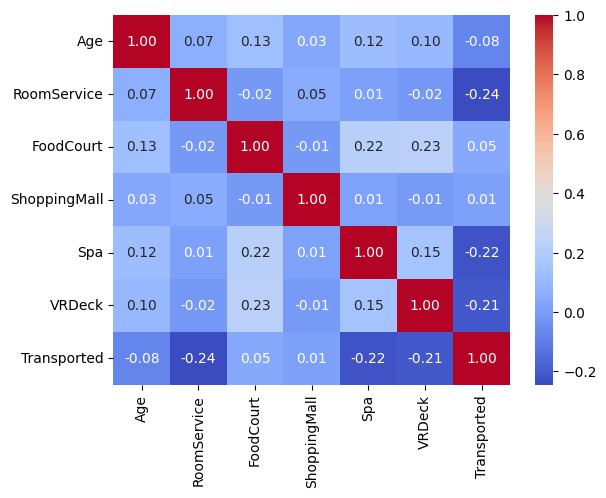

In [105]:
sns.heatmap(train_corr.corr(numeric_only=True), annot = True, fmt = '.2f', cmap = 'coolwarm')

### Observations — Correlation Heatmap

- Strongest linear correlations with Transported:
    - RoomService (-0.24), Spa (-0.22), VRDeck (-0.21) — all negative,
      confirming leisure spending correlates with not being transported
    - FoodCourt (0.05), ShoppingMall (0.01) — near zero, utility 
      spending has no linear relationship with target
- CryoSleep excluded from heatmap (object dtype) — would be the 
  strongest predictor if included, confirmed in Section 5.3
- All correlations are relatively weak (<0.25) suggesting relationships 
  are largely non-linear — tree-based models will capture this better 
  than linear models
- Spending columns show mild inter-correlations (FoodCourt/VRDeck 0.23, 
  FoodCourt/Spa 0.22) — expected since high-spending passengers tend to 
  use multiple amenities

## 8. Key Findings and Next Steps

### Top EDA Findings

1. **CryoSleep is the dominant predictor** — 82% transport rate when True 
   vs 33% when False, a 50 point gap no other feature approaches. CryoSleep 
   also mechanically explains zero spending across all amenity columns, 
   making it central to both imputation strategy and modeling.

2. **Cabin structure reveals strong transport signal** — parsing Cabin into 
   Deck, Number, and Side reveals meaningful variation. Decks B and C have 
   73% and 68% transport rates while Deck E sits at 36%. Cabin_Side shows 
   a consistent 10 point gap (Starboard 55% vs Port 45%). Three features 
   from one column.

3. **HomePlanet is strongly predictive and correlated with Cabin** — Europa 
   (66%) > Mars (52%) > Earth (42%). Europa passengers cluster in high-transport 
   Decks B and C, Earth passengers in lower-transport Decks F and G. These two 
   features partially encode the same signal — worth monitoring for 
   multicollinearity in modeling.

4. **Leisure vs utility spending asymmetry** — RoomService, Spa, and VRDeck 
   all show higher median spending for non-transported passengers. FoodCourt 
   and ShoppingMall show no meaningful difference. Active leisure engagement 
   with the ship correlates with not being transported. Will engineer 
   LeisureSpend and UtilitySpend as separate features to capture this.

5. **PassengerId encodes group travel structure** — the gggg_pp format reveals 
   that ~55% of passengers traveled alone. Group size and solo travel status 
   are potentially predictive features not visible in any other column.

### Feature Engineering Plan (Notebook 02)

| Feature | Source | Rationale |
|---|---|---|
| `Group` | PassengerId | Extract group ID |
| `GroupSize` | PassengerId | Count passengers per group |
| `IsAlone` | GroupSize | Solo traveler flag |
| `Cabin_Deck` | Cabin | Strong transport rate signal |
| `Cabin_Num_Binned` | Cabin | Ship corridor position |
| `Cabin_Side` | Cabin | 10pt transport rate gap |
| `AgeBin` | Age | Child threshold effect |
| `TotalSpend` | All spending | Overall spending level |
| `LeisureSpend` | RoomService + Spa + VRDeck | Predictive spending type |
| `UtilitySpend` | FoodCourt + ShoppingMall | Non-predictive spending type |
| `IsAwakeZeroSpender` | CryoSleep + TotalSpend | Suspicious zero spenders |
| `FamilySize` | Name | Surname frequency (Earth passengers) |

### Preprocessing Plan (Notebook 02)

- **Imputation:** Logical first (CryoSleep ↔ spending), then median for 
  numerical, mode for categorical — fit on train only, applied to test
- **Encoding:** One-hot for low-cardinality categoricals (HomePlanet, 
  Destination, Cabin_Deck, Cabin_Side), binary for booleans
- **Scaling:** StandardScaler for numerical features (required for 
  Logistic Regression, optional for tree models)
- **Transformation:** log1p for all spending columns before modeling